# Clase 1 — Alta dimensionalidad y el problema p ≫ n

**Maestría en Bioinformática y Biología de Sistemas — UNNOBA**
**Reconocimiento de Patrones en Bioinformática**

---

## Objetivos de esta clase


1. Reconocer cuándo un dataset es de **alta dimensionalidad** (régimen p ≫ n) y por qué eso es problemático.
2. Entender la **maldición de la dimensionalidad** desde tres puntos de vista: geométrico, computacional y estadístico.
3. Ver empíricamente por qué los métodos clásicos de Minería de Datos **fallan silenciosamente** en este régimen.
4. Aplicar correcciones por **testeo múltiple** (Bonferroni, Benjamini-Hochberg) y entender la diferencia entre **FWER** y **FDR**.


## Antes de empezar

> Si te falta alguna librería, descomentá la siguiente celda (borra el #) y ejecutala.

In [ ]:
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels --quiet

In [ ]:
# Setup general
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Setup listo. Versiones:")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")
import sklearn; print(f"  sklearn {sklearn.__version__}")

Setup listo. Versiones:
  numpy   2.0.2
  pandas  2.2.2
  sklearn 1.6.1


---

#  Datos ómicos y el régimen p ≫ n

## ¿Qué tienen de especial los datos biológicos?

En Minería de Datos trabajaste seguramente con datasets como los de UCI o Kaggle: filas que son **muestras** (pacientes, clientes, transacciones) y columnas que son **variables** (edad, ingresos, número de compras). Típicamente había **muchas más filas que columnas**.

En bioinformática esto **se invierte**. Mirá estos tamaños reales:

| Tipo de dato | Muestras (n) | Variables (p) | Ratio p/n |
|---|---|---|---|
| Microarray de expresión | 20–200 | 20.000 | ~100 |
| RNA-seq bulk | 50–500 | 60.000 | ~120 |
| RNA-seq single-cell | 5.000–500.000 | 30.000 | 0.06–6 |
| Proteómica MS | 20–200 | 5.000–10.000 | ~50 |
| Metabolómica | 50–300 | 500–2.000 | ~5 |
| GWAS | 1.000–500.000 | 500.000–10⁷ | 20–10.000 |
| Metagenómica 16S | 50–1.000 | 1.000–100.000 | 20–100 |

Cuando **p ≫ n** (muchas más variables que muestras), entramos en un régimen donde la **intuición estadística clásica deja de funcionar**.

## Definición operativa

Hablamos de **alta dimensionalidad** cuando se cumple que $p > n$

Caso fuerte: $p > n$ (más variables que muestras). Acá la regresión clásica directamente no tiene solución única.
Caso intermedio: $p < n$ pero $p/n > 0.1$ aproximadamente, ejemplo 100 variables y 500 muestras. Acá sí hay solución, pero los métodos clásicos empiezan a sufrir: alta varianza en los coeficientes, sobreajuste, intervalos de confianza poco confiables.

La regla mental que conviene tener: mirá el ratio p/n, no solo p. Con n=10.000 y p=1.000, p/n = 0.1 y casi todo anda bien. Con n=50 y p=100, p/n = 2 y ya hay problemas serios aunque sea p < n por nada.

## Veamos qué quiere decir esto en código

In [ ]:
# Simulemos un experimento típico de microarray:
# n = 50 pacientes (25 sanos, 25 enfermos)
# p = 5000 genes medidos
# Sólo 10 de esos 5000 genes están REALMENTE diferenciados entre clases.

n_per_class = 25
n = 2 * n_per_class
p = 5000
n_signal = 10        # genes verdaderamente diferenciados
effect_size = 1.5    # cuán fuerte es la diferencia

# Generamos ruido para todas las variables: N(0, 1)
X = np.random.randn(n, p)

# Etiquetas: primeras 25 sanas (0), siguientes 25 enfermas (1)
y = np.array([0]*n_per_class + [1]*n_per_class)

# Agregamos señal en los primeros n_signal genes para los enfermos
X[y == 1, :n_signal] += effect_size

print(f"Dataset:  n = {n} muestras, p = {p} variables")
print(f"Ratio p/n = {p/n:.0f}")
print(f"Señal real: sólo en {n_signal} de {p} genes ({100*n_signal/p:.2f}% de las variables)")
print(f"Estructura de datos(muestras, genes) = {X.shape}")
print(f"Muestras = {y.shape}, n de cada clase: {np.bincount(y)}")

Dataset:  n = 50 muestras, p = 5000 variables
Ratio p/n = 100
Señal real: sólo en 10 de 5000 genes (0.20% de las variables)
Estructura de datos(muestras, genes) = (50, 5000)
Muestras = (50,), n de cada clase: [25 25]


**Observá la forma**: la matriz $X$ es "ancha y baja". Esa forma es lo característico de los datos ómicos.

## Ejercicio 1 — Explorando la forma del problema (5 min)

Imaginá que sos un investigador y recibís este dataset. Algunas preguntas básicas:

1. ¿Cuántos genes podrían parecer "diferentes entre clases" sólo por azar, si aplicaras un test t de student a cada gen con un umbral de p-valor < 0.05?
2. Si el ratio p/n fuera **al revés** (5000 muestras y 50 genes), ¿cuál sería tu intuición sobre la facilidad del problema?
3. Calculá la **media** y el **desvío estándar** del gen 0 (que SÍ tiene señal) y del gen 100 (que NO tiene señal) para cada clase. ¿Cuán diferentes parecen?

> Completá las celdas siguientes:

In [ ]:
# Pregunta 1: ¿Cuántos falsos positivos esperarías por azar?
# Pista: si el test es válido bajo H0, ~5% de los tests bajo H0 cierta dan p < 0.05.

# TU CÓDIGO ACÁ
falsos_positivos_esperados = ...
print(f"Genes que esperaríamos ver como 'significativos' sólo por azar: {falsos_positivos_esperados}")

In [ ]:
# Pregunta 3: media y desvío de gen 0 (señal) y gen 100 (ruido) por clase
gen_signal = 0
gen_noise = 100

# TU CÓDIGO ACÁ
# Sugerencia: usá X[y == 0, gen_signal] para acceder a los valores del gen 0 en clase 0

print("Gen 0 (con señal):")
print(f"  Clase 0: media = ..., sd = ...")
print(f"  Clase 1: media = ..., sd = ...")
print()
print("Gen 100 (sin señal):")
print(f"  Clase 0: media = ..., sd = ...")
print(f"  Clase 1: media = ..., sd = ...")

¿La diferencia entre clases en el gen con señal es "obvia" a ojo? ¿Y si tuvieras que decidir entre 5000 genes, sin saber cuáles tienen señal?

---

# La maldición de la dimensionalidad
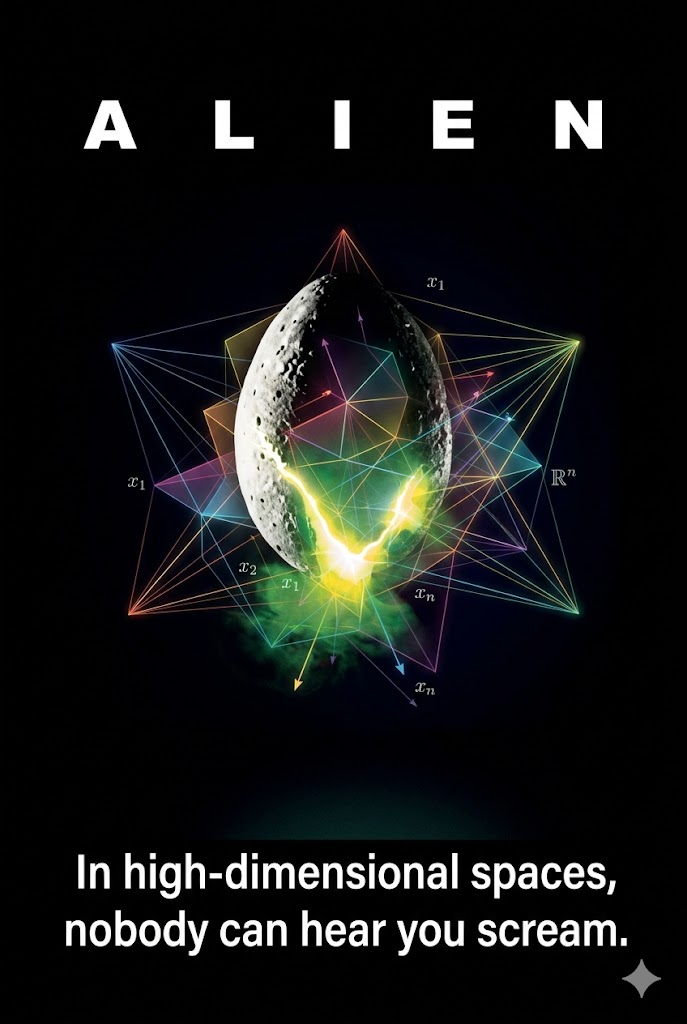




La **maldición de la dimensionalidad** (curse of dimensionality, Bellman 1961) es un conjunto de fenómenos contraintuitivos que ocurren cuando la dimensión $p$ crece. Vamos a ver tres caras del problema.

## Cara 1 — El volumen del espacio crece exponencialmente

Pensá en una grilla de puntos espaciados a distancia 0.1 dentro de un hipercubo unitario $[0,1]^p$:

- En $p = 1$: 10 puntos.
- En $p = 2$: 100 puntos.
- En $p = 10$: $10^{10}$ puntos (diez mil millones).
- En $p = 100$: $10^{100}$ puntos.

**Consecuencia:** cualquier muestra de tamaño realista cubre una fracción infinitesimal del espacio. Los datos son **escasos** (sparse) en alta dimensión.

## Cara 2 — Las distancias se concentran

En alta dimensión, **todas las distancias entre puntos tienden a ser parecidas entre sí**. Esto rompe métodos basados en distancia como KNN: el "vecino más cercano" deja de ser claramente más cercano que el "vecino más lejano".

Veámoslo:

In [ ]:
def concentracion_distancias(n_puntos=100, dimensiones=None):
    """
    Para cada dimensión p, genera n_puntos uniformes en [0,1]^p,
    calcula todas las distancias entre pares y reporta:
    - distancia mínima
    - distancia máxima
    - el ratio (max - min) / min  (cuánto se separa el lejano del cercano)
    """
    if dimensiones is None:
        dimensiones = [1, 2, 5, 10, 50, 100, 500, 1000, 5000]
    resultados = []
    for p in dimensiones:
        X = np.random.rand(n_puntos, p)
        # Distancias entre todos los pares
        diffs = X[:, None, :] - X[None, :, :]
        dists = np.sqrt((diffs**2).sum(axis=2))
        # Sólo el triángulo superior (sin la diagonal)
        triu = dists[np.triu_indices(n_puntos, k=1)]
        d_min, d_max = triu.min(), triu.max()
        ratio = (d_max - d_min) / d_min
        resultados.append({
            "p": p,
            "d_min": d_min,
            "d_max": d_max,
            "ratio_(max-min)/min": ratio
        })
    return pd.DataFrame(resultados)

df_dist = concentracion_distancias()
print(df_dist.to_string(index=False))

   p     d_min     d_max  ratio_(max-min)/min
   1  0.000002  0.964244        454828.692789
   2  0.008527  1.273849           148.391651
   5  0.136965  1.689964            11.338640
  10  0.370903  2.114415             4.700726
  50  1.878762  3.750090             0.996043
 100  3.078754  4.952019             0.608449
 500  8.254985  9.991737             0.210388
1000 12.031213 13.804477             0.147389
5000 27.765209 29.746776             0.071369


Notá cómo el ratio $(d_{max} - d_{min}) / d_{min}$ tiende a cero a medida que $p$ crece. Esto significa que el punto más lejano y el más cercano están casi a la misma distancia: la noción de "vecino" se diluye.

## Cara 3 — El volumen se concentra en los bordes

Otro fenómeno raro: en alta dimensión, casi todo el volumen del hipercubo está cerca de los bordes y muy poco en el "centro". Para una hiperesfera inscrita en el hipercubo unitario, el ratio (volumen esfera) / (volumen cubo) tiende a 0 cuando $p \to \infty$.

### Visualizando el Hipercubo y la Hiperesfera (2D)

Para entender el concepto de que el volumen se concentra en los bordes en altas dimensiones, podemos empezar con una visualización simple en 2D. Aquí, un círculo (representando una hiperesfera) está inscrito dentro de un cuadrado (representando un hipercubo).

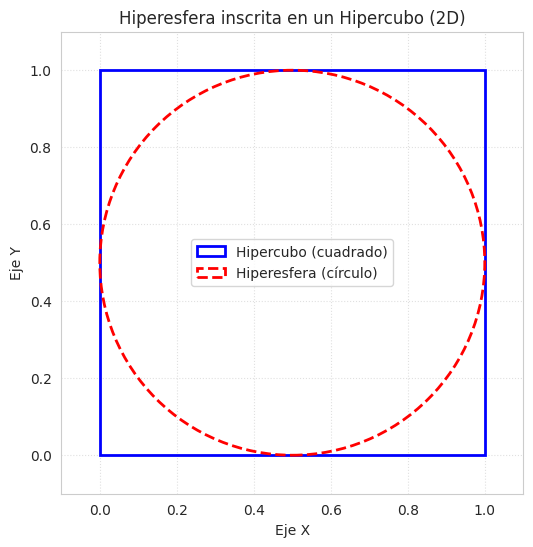

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6, 6))

# Dibujar el hipercubo (cuadrado unitario)
# El cuadrado va de (0,0) a (1,1)
ax.add_patch(patches.Rectangle((0, 0), 1, 1, edgecolor='blue', facecolor='none', lw=2, label='Hipercubo (cuadrado)'))

# Dibujar la hiperesfera (círculo inscrito)
# El centro del círculo es (0.5, 0.5) y el radio es 0.5
circle = patches.Circle((0.5, 0.5), 0.5, edgecolor='red', facecolor='none', lw=2, linestyle='--', label='Hiperesfera (círculo)')
ax.add_patch(circle)

# Configuración del plot
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Hiperesfera inscrita en un Hipercubo (2D)')
ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

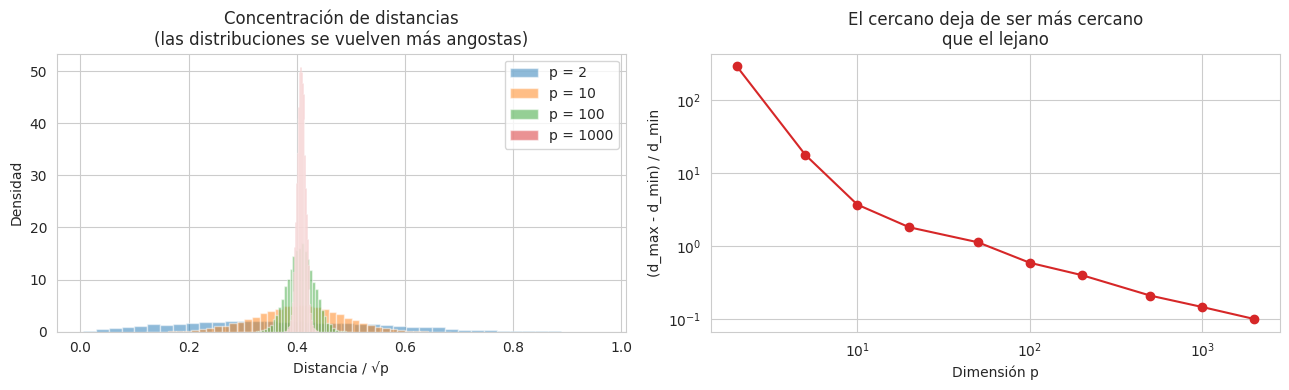

In [ ]:
# Visualizamos la concentración de distancias
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de distancias para varias dimensiones
n_puntos = 200
for p, color in zip([2, 10, 100, 1000], ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
    X = np.random.rand(n_puntos, p)
    diffs = X[:, None, :] - X[None, :, :]
    dists = np.sqrt((diffs**2).sum(axis=2))
    triu = dists[np.triu_indices(n_puntos, k=1)]
    # Normalizamos por sqrt(p) para que sean comparables
    axes[0].hist(triu / np.sqrt(p), bins=40, alpha=0.5,
                 label=f"p = {p}", color=color, density=True)

axes[0].set_xlabel("Distancia / √p")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Concentración de distancias\n(las distribuciones se vuelven más angostas)")
axes[0].legend()

# Ratio max/min vs dimensión
df_plot = concentracion_distancias(n_puntos=100,
                                    dimensiones=[2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000])
axes[1].plot(df_plot["p"], df_plot["ratio_(max-min)/min"], "o-", color="tab:red")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Dimensión p")
axes[1].set_ylabel("(d_max - d_min) / d_min")
axes[1].set_title("El cercano deja de ser más cercano\nque el lejano")

plt.tight_layout()
plt.show()

## Ejercicio 2 — KNN en alta dimensión (10 min)

Vamos a verificar empíricamente que **KNN se degrada con la dimensión**, incluso manteniendo constante la señal real.

**Setup del experimento:**
- Generamos un dataset con $n = 200$ muestras y $p$ variables variable.
- Sólo las **primeras 5 variables** son informativas (separan las clases).
- El resto son **puro ruido**.
- Entrenamos un KNN y evaluamos el accuracy (exactitud) en test.

Si la dimensionalidad fuera "inocua", el accuracy debería **mantenerse**: la información útil siempre está. Pero...

## Recordatorio: Accuracy (Exactitud) y Precisión

-   **Accuracy (Exactitud):** Es la proporción de predicciones correctas sobre el total de predicciones. Responde a la pregunta: *¿Qué tan cerca están mis mediciones del valor verdadero?* En clasificación, es el número de predicciones correctas (verdaderos positivos + verdaderos negativos) dividido por el total de muestras.
$$\text{Accuracy (Exactitud)} = \left[\frac{\text{ predicciones correctas}}{\text{total de predicciones}}\right] = \left[\frac{\text{TP+TN}}{\text{ TP + TN + FP + FN}}\right]$$


-   **Precisión:** Se refiere a la repetibilidad de las mediciones, es decir, qué tan cerca están entre sí los resultados de varias mediciones de la misma cantidad. En el contexto de clasificación, para una clase específica, la precisión es la proporción de verdaderos positivos (TP) sobre el total de elementos identificados como positivos (TP + falsos positivos, FP).
$$\text{Precisión} = \left[\frac{\text{Positivos reales}}{\text{ Positivos totales}}\right]=  \left[\frac{\text{TP}}{\text{ TP + FP}}\right]$$

p =     5  →  accuracy promedio = 0.989
p =    10  →  accuracy promedio = 0.983
p =    50  →  accuracy promedio = 0.955
p =   100  →  accuracy promedio = 0.931
p =   500  →  accuracy promedio = 0.791
p =  1000  →  accuracy promedio = 0.704
p =  5000  →  accuracy promedio = 0.619


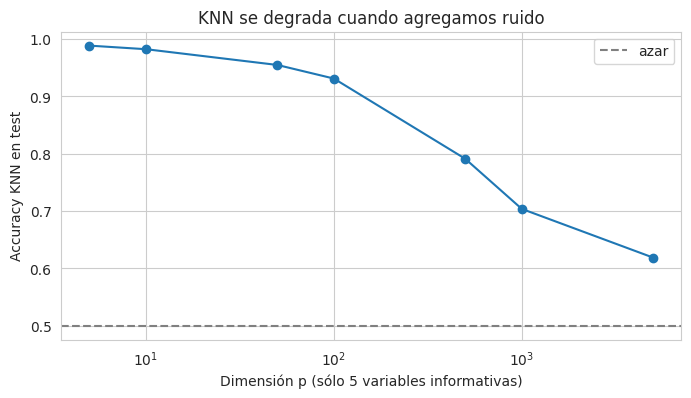

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

def experimento_knn(p, n=200, n_informativas=5, effect_size=2.0, seed=0):
    rng = np.random.RandomState(seed)
    X = rng.randn(n, p)
    y = rng.randint(0, 2, size=n)
    # Señal real sólo en las primeras n_informativas variables
    X[y == 1, :n_informativas] += effect_size

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.4, random_state=seed)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(Xtr, ytr)
    return knn.score(Xte, yte)

# TU TAREA: completá el bucle para evaluar accuracy en función de p
dimensiones = [5, 10, 50, 100, 500, 1000, 5000]
accuracies = []

# TU CÓDIGO ACÁ
# Promediá sobre, digamos, 10 semillas para reducir varianza

for p in dimensiones:
    accs = [experimento_knn(p, seed=s) for s in range(10)]
    accuracies.append(np.mean(accs))
    print(f"p = {p:>5d}  →  accuracy promedio = {np.mean(accs):.3f}")

plt.figure(figsize=(8, 4))
plt.plot(dimensiones, accuracies, "o-")
plt.axhline(0.5, color="gray", linestyle="--", label="azar")
plt.xscale("log")
plt.xlabel("Dimensión p (sólo 5 variables informativas)")
plt.ylabel("Accuracy KNN en test")
plt.title("KNN se degrada cuando agregamos ruido")
plt.legend()
plt.show()

> La señal siempre está ahí (en las primeras 5 variables). Pero el clasificador no la puede encontrar porque las distancias quedan dominadas por las 4995 variables de ruido. **Moraleja:** "tirar todo y dejar que el algoritmo aprenda" no funciona en alta dimensión. Hay que **seleccionar variables** (próxima clase).

---

# Separabilidad espuria

Acá viene uno de los fenómenos más peligrosos del régimen p ≫ n:

> **Con suficientes variables aleatorias, podés separar perfectamente cualquier conjunto de etiquetas, incluso si no hay ninguna relación real.**

Esto es lo que se llama **separabilidad espuria** o **sobreajuste estructural**. Lo grave es que **sucede en silencio**: el accuracy en train es altísimo, y si validás mal, también el de test.

## Demostración: clases asignadas al azar

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

# Generamos datos donde NO HAY NINGUNA RELACIÓN entre X e y
n = 50
p_values = [10, 100, 1000, 5000]

print("Datos puramente aleatorios — no hay relación X→y")
print("=" * 60)
print(f"{'p':>6} | {'Acc train':>10} | {'Acc test (mal)':>15} | {'Acc CV (bien)':>14}")
print("-" * 60)

for p in p_values:
    X = np.random.randn(n, p)
    y = np.random.randint(0, 2, size=n)

    # MAL: entrenamos y testeamos en los mismos datos
    rf = RandomForestClassifier(n_estimators=100, random_state=0)
    rf.fit(X, y)
    acc_train = rf.score(X, y)

    # MÁS O MENOS: una sola partición train/test
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
    rf2 = RandomForestClassifier(n_estimators=100, random_state=0)
    rf2.fit(Xtr, ytr)
    acc_test = rf2.score(Xte, yte)

    # BIEN: cross-validation
    acc_cv = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=0),
        X, y, cv=5
    ).mean()

    print(f"{p:>6} | {acc_train:>10.3f} | {acc_test:>15.3f} | {acc_cv:>14.3f}")

Datos puramente aleatorios — no hay relación X→y
     p |  Acc train |  Acc test (mal) |  Acc CV (bien)
------------------------------------------------------------
    10 |      1.000 |           0.400 |          0.560
   100 |      1.000 |           0.667 |          0.580
  1000 |      1.000 |           0.800 |          0.600
  5000 |      1.000 |           0.333 |          0.600


**Observá la primera columna:** el accuracy en train es siempre **1.00**. Random Forest puede separar perfectamente cualquier asignación de etiquetas. Pero las etiquetas son **completamente aleatorias** — no hay nada que aprender.

**El verdadero accuracy** (CV) está cerca del 50% (azar), como debe ser. Pero si validaras mal (mirando sólo train, o haciendo una única partición con suerte), podrías reportar un "clasificador" que en realidad no existe.

## ¿Por qué esto importa?

Esto es **exactamente** lo que ocurre en muchos papers de bioinformática mal validados:

1. Recolectan datos ómicos de pocos pacientes.
2. Tienen miles de variables.
3. Entrenan un clasificador con accuracy 95%.
4. Lo publican como "biomarcador".
5. **Nadie puede reproducirlo.**

Vamos a hacer un experimento aún más perturbador.

## Ejercicio 3 — La selección que engaña

El error metodológico más frecuente:

1. Tomar TODOS los datos (train + test juntos).
2. Seleccionar las "mejores" variables (las más correlacionadas con y).
3. Hacer cross-validation usando esas variables.

Esto está **MAL** (es data leakage; lo veremos en detalle en la Clase 6),, brevemente, Data leakage es cuando información del conjunto de test (o del futuro, o de la respuesta) se filtra al entrenamiento de un modelo, inflando artificialmente la performance medida. El caso más clásico: hacer corrección/normalización/selección de variables usando todos los datos antes de separar en train y test. El test ya "vio" cosas del train (medias, varianzas, qué variables son relevantes), entonces cuando lo evaluás te da mejor de lo que daría en datos verdaderamente nuevos
Veamos qué tan engañoso es.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

n = 50
p = 5000
# DATOS PURAMENTE ALEATORIOS — y NO depende de X
X = np.random.randn(n, p)
y = np.random.randint(0, 2, size=n)

# ❌ MAL: seleccionar las 20 mejores variables ANTES del CV
selector = SelectKBest(f_classif, k=20)
X_filtrado = selector.fit_transform(X, y)  # usa toda la información de y

acc_mal = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_filtrado, y, cv=5
).mean()

# ✅ BIEN: seleccionar las 20 mejores DENTRO del CV
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ("selector", SelectKBest(f_classif, k=20)),
    ("clf", LogisticRegression(max_iter=1000))
])
acc_bien = cross_val_score(pipeline, X, y, cv=5).mean()

print(f"Accuracy con selección MAL hecha (data leakage): {acc_mal:.3f}")
print(f"Accuracy con selección BIEN hecha (en pipeline): {acc_bien:.3f}")
print()
print("Recordá: NO hay relación entre X e y. El accuracy real es 0.5.")

Accuracy con selección MAL hecha (data leakage): 0.980
Accuracy con selección BIEN hecha (en pipeline): 0.540

Recordá: NO hay relación entre X e y. El accuracy real es 0.5.


**Tarea:** repetí el experimento variando $p$ y reportá ambos accuracies. ¿Cuán grande puede ser el sesgo?

In [ ]:
# TU CÓDIGO ACÁ:
# Repetí para p en [100, 500, 1000, 5000, 10000] y graficá ambos accuracies.

p_values = [100, 500, 1000, 5000, 10000]
acc_mal_list = []
acc_bien_list = []

# COMPLETÁ EL BUCLE

# COMPLETÁ LA VISUALIZACIÓN

---

# Testeo múltiple, FWER y FDR

Volvamos al problema concreto que abre la mayoría de los pipelines bioinformáticos: identificar **genes diferencialmente expresados** entre dos condiciones.

## El planteo

Por cada gen $j$, planteamos:

- $H_0^{(j)}$: el gen $j$ no está diferenciado entre clases.
- $H_1^{(j)}$: el gen $j$ está diferenciado.

Aplicamos un test t (o de Wilcoxon) y obtenemos un p-valor $p_j$.

## El problema

Si tenés un **único** test y rechazás $H_0$ cuando $p < 0.05$, la probabilidad de un falso positivo es 5%. **Aceptable.**

Pero si hacés **5000 tests** simultáneos y aplicás el mismo umbral 0.05:

- Aún cuando **TODAS** las hipótesis nulas sean ciertas (ningún gen está diferenciado),
- esperás $0.05 \times 5000 = 250$ "descubrimientos" falsos.

Esto se llama el **problema del testeo múltiple**.

## Veámoslo

In [ ]:
# Volvemos a nuestro dataset simulado del Bloque 1
# Recordá: 10 genes con señal real, 4990 puro ruido

n_per_class = 25
n = 2 * n_per_class
p = 5000
n_signal = 100
effect_size = 1.5

np.random.seed(42)
X = np.random.randn(n, p)
y = np.array([0]*n_per_class + [1]*n_per_class)
X[y == 1, :n_signal] += effect_size

# Aplicamos un test t a cada gen (vectorizado: un solo llamado a scipy)
from scipy.stats import ttest_ind

_, pvalores = ttest_ind(X[y == 0], X[y == 1], axis=0)

# ¿Cuántos genes "salen significativos" con un umbral ingenuo de 0.05?
descubrimientos = np.where(pvalores < 0.05)[0]
print(f"Genes con p < 0.05: {len(descubrimientos)}")
print(f"  De ellos, REALES (entre los primeros {n_signal}): {sum(descubrimientos < n_signal)}")
print(f"  De ellos, FALSOS POSITIVOS: {sum(descubrimientos >= n_signal)}")

Genes con p < 0.05: 324
  De ellos, REALES (entre los primeros 100): 100
  De ellos, FALSOS POSITIVOS: 224


La lista de "genes significativos" está **dominada por falsos positivos**. Si publicaras esta lista como biomarcadores, estarías mintiendo (aunque no lo sepas).

## Dos criterios para corregir

### Family-Wise Error Rate (FWER)

$$\text{FWER} = P(\text{al menos un FP}) = 1 - (1 - α)^m $$

Querés controlar la probabilidad de tener **CUALQUIER** falso positivo. Es muy conservador.

**Bonferroni** controla FWER: usa el umbral $\alpha / m$ en lugar de $\alpha$, donde $m$ es el número de tests.

### False Discovery Rate (FDR)

$$\text{FDR} = E\left[\frac{\text{falsos positivos}}{\text{descubrimientos totales}}\right]$$

Querés controlar la **proporción** esperada de falsos positivos entre tus descubrimientos. Menos conservador, más útil en ómicas.

**Benjamini-Hochberg (BH, 1995)** controla FDR. Es el estándar de facto en RNA-seq, microarrays, proteómica, GWAS, etc.

In [ ]:
from statsmodels.stats.multitest import multipletests

# Bonferroni
reject_bonf, pvals_bonf, _, _ = multipletests(pvalores, alpha=0.05, method="bonferroni")

# Benjamini-Hochberg (FDR)
reject_bh, pvals_bh, _, _ = multipletests(pvalores, alpha=0.05, method="fdr_bh")

print("Resultados de los 3 criterios:")
print(f"  Sin corrección (p < 0.05):  {pvalores.thresh if False else (pvalores < 0.05).sum()} descubrimientos")
print(f"     TP={((pvalores < 0.05) & (np.arange(p) < n_signal)).sum()}, "
      f"FP={((pvalores < 0.05) & (np.arange(p) >= n_signal)).sum()}")
print()
print(f"  Bonferroni (FWER < 0.05):   {reject_bonf.sum()} descubrimientos")
print(f"     TP={(reject_bonf & (np.arange(p) < n_signal)).sum()}, "
      f"FP={(reject_bonf & (np.arange(p) >= n_signal)).sum()}")
print()
print(f"  Benjamini-Hochberg (FDR < 0.05): {reject_bh.sum()} descubrimientos")
print(f"     TP={(reject_bh & (np.arange(p) < n_signal)).sum()}, "
      f"FP={(reject_bh & (np.arange(p) >= n_signal)).sum()}")

Resultados de los 3 criterios:
  Sin corrección (p < 0.05):  324 descubrimientos
     TP=100, FP=224

  Bonferroni (FWER < 0.05):   68 descubrimientos
     TP=68, FP=0

  Benjamini-Hochberg (FDR < 0.05): 103 descubrimientos
     TP=98, FP=5


**Lectura del resultado:**

- **Sin corrección:** muchos descubrimientos, pero contaminados con falsos positivos.
- **Bonferroni:** muy estricto. Pierde verdaderos positivos pero asegura casi cero falsos positivos.
- **Benjamini-Hochberg:** balance razonable. Permite algún falso positivo a cambio de muchos más verdaderos.

En la mayoría de los análisis ómicos modernos, el estándar es **BH con FDR < 0.05** (a veces 0.10).

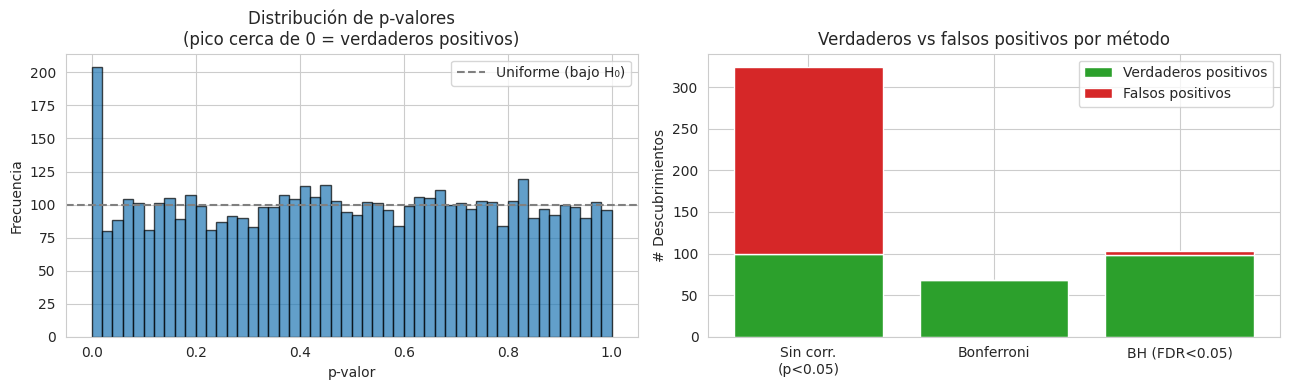

In [ ]:
# Visualización: distribución de p-valores
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de p-valores
axes[0].hist(pvalores, bins=50, edgecolor="black", alpha=0.7)
axes[0].axhline(p/50, color="gray", linestyle="--", label="Uniforme (bajo H₀)")
axes[0].set_xlabel("p-valor")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de p-valores\n(pico cerca de 0 = verdaderos positivos)")
axes[0].legend()

# Comparación de los 3 métodos
metodos = ["Sin corr.\n(p<0.05)", "Bonferroni", "BH (FDR<0.05)"]
tp = [((pvalores < 0.05) & (np.arange(p) < n_signal)).sum(),
      (reject_bonf & (np.arange(p) < n_signal)).sum(),
      (reject_bh & (np.arange(p) < n_signal)).sum()]
fp = [((pvalores < 0.05) & (np.arange(p) >= n_signal)).sum(),
      (reject_bonf & (np.arange(p) >= n_signal)).sum(),
      (reject_bh & (np.arange(p) >= n_signal)).sum()]

x = np.arange(len(metodos))
axes[1].bar(x, tp, label="Verdaderos positivos", color="tab:green")
axes[1].bar(x, fp, bottom=tp, label="Falsos positivos", color="tab:red")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metodos)
axes[1].set_ylabel("# Descubrimientos")
axes[1].set_title("Verdaderos vs falsos positivos por método")
axes[1].legend()

plt.tight_layout()
plt.show()

## Ejercicio 4 — Sensibilidad del FDR

Vamos a explorar cómo cambia el resultado de BH al variar dos cosas:

1. El **tamaño de muestra** ($n$).
2. El **tamaño del efecto** (`effect_size`).

**Tu tarea:**

a) Variá `n_per_class` entre 5, 10, 25, 50 y reportá cuántos verdaderos positivos detecta BH (con FDR < 0.05), manteniendo `effect_size = 1.5` y `n_signal = 10`.

b) Hacé lo mismo variando `effect_size` entre 0.5, 1.0, 1.5, 2.0, 3.0, con `n_per_class = 25`.

In [ ]:
def correr_experimento(n_per_class=25, effect_size=1.5, n_signal=10, p=5000, seed=42):
    rng = np.random.RandomState(seed)
    n = 2 * n_per_class
    X = rng.randn(n, p)
    y = np.array([0]*n_per_class + [1]*n_per_class)
    X[y == 1, :n_signal] += effect_size

    # Test t vectorizado (un solo llamado para todos los genes)
    _, pvalores = ttest_ind(X[y == 0], X[y == 1], axis=0)
    reject_bh, _, _, _ = multipletests(pvalores, alpha=0.05, method="fdr_bh")
    tp = (reject_bh & (np.arange(p) < n_signal)).sum()
    fp = (reject_bh & (np.arange(p) >= n_signal)).sum()
    return tp, fp

# (a) Variando n_per_class
print("Variando tamaño de muestra (effect_size = 1.5):")
print(f"{'n_per_class':>12} | {'TP':>4} | {'FP':>4}")

# TU CÓDIGO ACÁ
# Sugerencia: promediá TP y FP sobre 10 semillas para cada n_per_class

print()
print("Variando tamaño del efecto (n_per_class = 25):")
print(f"{'effect_size':>12} | {'TP':>4} | {'FP':>4}")

# TU CÓDIGO ACÁ

> ¿Qué te dice esto sobre el diseño experimental? Si tu efecto biológico es pequeño, ¿podés compensarlo aumentando $n$? ¿Hay un piso por debajo del cual BH "no ve" la señal?

---

# Cierre integrador

## Que vimos:

| Concepto | Idea clave |
|---|---|
| **p ≫ n** | Datos ómicos tienen miles de variables y decenas de muestras. La intuición clásica deja de funcionar. |
| **Maldición de la dimensionalidad** | Las distancias se concentran, el espacio queda vacío, KNN se rompe. |
| **Separabilidad espuria** | Cualquier clasificador puede separar etiquetas aleatorias en alta dimensión. |
| **Testeo múltiple** | Con 5000 tests, hay que corregir el umbral o ahogarte en falsos positivos. |
| **Bonferroni vs BH** | Bonferroni controla la probabilidad de cualquier FP (FWER). BH controla la proporción esperada (FDR). BH es el estándar en ómicas. |

## El recorrido del curso

Hoy diagnosticamos el problema. En las próximas clases vamos a construir las herramientas para resolverlo:

- **Clase 2:** Cómo seleccionar variables sin caer en data leakage.
- **Clase 3:** Cómo visualizar y reducir la dimensión (PCA, UMAP).
- **Clase 4:** Cómo regularizar modelos para que funcionen en p ≫ n (Lasso, Ridge).
- **Clase 5:** Métodos no lineales que escalan bien: SVM y kernels.
- **Clase 6:** Validación correcta, interpretabilidad, introducción a deep learning.

## Ejercicio 5 — Integrador (5 min)

Imaginá que un colaborador te trae los siguientes resultados de un experimento RNA-seq:

> "Comparé 8 pacientes vs 8 controles en 30.000 genes. Encontré 1.834 genes diferencialmente expresados con p < 0.05 sin corregir. Voy a hacer un Random Forest con esos genes y validarlo con leave-one-out CV. Espero un accuracy alto, eso confirmaría que son biomarcadores reales."

Listá **al menos tres** problemas metodológicos en este plan y proponé correcciones.

> Escribí tus respuestas en la celda Markdown de abajo:

**Tu respuesta:**

1. _(problema 1)_ → _(corrección 1)_
2. _(problema 2)_ → _(corrección 2)_
3. _(problema 3)_ → _(corrección 3)_

---

## Recursos y bibliografía

Mirá el archivo `bibliografia_clase1.md` que acompaña este notebook. Allí vas a encontrar:

- Artículos fundacionales (Benjamini-Hochberg 1995, etc.).
- Capítulos relevantes de los libros del curso.
- **Videos de StatQuest y otros canales** para repasar conceptos visualmente.
